# OCR Evaluation (PaddleOCR)

## Phương pháp scan so sánh
1. **original** — vùng tương ứng trên ảnh gốc (vẫn méo perspective) — baseline
2. **warped_gray** — vùng crop trên ảnh warped, xám
3. **otsu** — Otsu thresholding
4. **adaptive** — Adaptive Gaussian threshold
5. **clahe_otsu** — CLAHE + Otsu
6. **color** — Color-preserving (background division)

## Cách chạy

1. Chạy cell **Đọc dữ liệu từ kaggle** để tải dữ liệu từ kaggle.
2. Chạy lần lượt các cell còn lại.


In [ ]:
%pip uninstall -y paddlepaddle paddlepaddle-gpu paddleocr paddlex > /dev/null 2>&1
%pip install -q python-Levenshtein
%pip install -q paddlepaddle==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/
%pip install -q paddleocr
%pip install -q langchain-text-splitters

import paddle
import paddleocr

print("Paddle version   :", paddle.__version__)
print("PaddleOCR version:", paddleocr.__version__)
print("CUDA compiled    :", paddle.is_compiled_with_cuda())

Paddle version   : 3.2.0
PaddleOCR version: 3.5.0
CUDA compiled    : False


In [ ]:
import json
import re
import tempfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from paddleocr import PaddleOCR
from Levenshtein import distance, ratio


## 1. Đọc data từ kaggle

In [ ]:
import os
from google.colab import files


!rm -rf ~/.cache/kaggle
!rm -rf /content/dataset

!kaggle datasets download -d tiendq/scanner --force
!unzip -q scanner.zip -d /content

In [ ]:
EVAL_DIR = Path('/content/dataset/test/eval_run')
WARPED_DIR = EVAL_DIR / 'warped'
TRANSFORMS_DIR = EVAL_DIR / 'transforms'
OCR_GT_PATH = EVAL_DIR / 'ocr_gt.json'
ORIGINAL_DIR = Path('/content/dataset/test')

RESULTS_CSV = EVAL_DIR / 'ocr_results_tesseract.csv'
SUMMARY_CSV = EVAL_DIR / 'ocr_summary_tesseract.csv'

ENGINE_NAME = 'paddleocr'
TMP_OCR_DIR = EVAL_DIR / '_tmp_paddleocr_inputs'
TMP_OCR_DIR.mkdir(parents=True, exist_ok=True)

print('EVAL_DIR    :', EVAL_DIR)
print('ORIGINAL_DIR:', ORIGINAL_DIR)
print('ENGINE_NAME :', ENGINE_NAME)
print('TMP_OCR_DIR :', TMP_OCR_DIR)


## 2. Đọc data từ drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# EVAL_DIR = Path('/content/drive/MyDrive/DataCV/dataset/test/eval_run')
# WARPED_DIR = EVAL_DIR / 'warped'
# TRANSFORMS_DIR = EVAL_DIR / 'transforms'
# OCR_GT_PATH = EVAL_DIR / 'ocr_gt.json'
# ORIGINAL_DIR = Path('/content/drive/MyDrive/DataCV/dataset/test')

# RESULTS_CSV = EVAL_DIR / 'ocr_results_paddleocr.csv'
# SUMMARY_CSV = EVAL_DIR / 'ocr_summary_paddleocr.csv'

# ENGINE_NAME = 'paddleocr'
# TMP_OCR_DIR = EVAL_DIR / '_tmp_paddleocr_inputs'
# TMP_OCR_DIR.mkdir(parents=True, exist_ok=True)

# print('EVAL_DIR    :', EVAL_DIR)
# print('ORIGINAL_DIR:', ORIGINAL_DIR)
# print('ENGINE_NAME :', ENGINE_NAME)
# print('TMP_OCR_DIR :', TMP_OCR_DIR)


EVAL_DIR    : /content/drive/MyDrive/DataCV/dataset/test/test_detection/eval_run
ORIGINAL_DIR: /content/drive/MyDrive/DataCV/dataset/test/test_detection
ENGINE_NAME : paddleocr
TMP_OCR_DIR : /content/drive/MyDrive/DataCV/dataset/test/test_detection/eval_run/_tmp_paddleocr_inputs


## 3. Load ground truth

In [ ]:
with open(OCR_GT_PATH, encoding='utf-8') as f:
    gt_data = json.load(f)

CROP_REGION = tuple(gt_data['crop_region'])
items = gt_data['items']
print(f'Ground truth có {len(items)} ảnh, crop_region = {CROP_REGION}\n')
for stem, info in items.items():
    print(f'  {stem}: {info["ground_truth"][:60]}...')

Ground truth có 18 ảnh, crop_region = (0.05, 0.06, 0.95, 0.16)

  z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26: I’ve always been keen on sport and very fit so a few years a...
  z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd: Điều khoản liên quan tới chương trình máy chương trình máy t...
  z7714827138018_2c6a64a819a53f7c09698670d1d0c3c3: Điều khoản liên quan tới chương trình máy chương trình máy t...
  z7714827142264_5ac4f8f41b14a8f38425b0c2e7bf576e: Điều khoản liên quan tới chương trình máy chương trình máy t...
  z7714827176964_651ecba060792771a088a276a71224c6: Thời gian Đầm thuận kiếm được. Đồng thời họ cũng hi vọng “mộ...
  2aOboQY0LBwLs4o8LQpYJ31H0OSflP7tBBHsTLTE: Output: chuyển thành thập phân ta tạo biến acc = 0 duyệt từ ...
  2aOboQY0LEFxDH3abPqjshfixAFuRAaJTAJ5BjiC: Hoa – Việt thân thiện đối với quân đội Tưởng Giới Thạch và v...
  2aOboQY0L8fcafZOXWcTbRm76XS8xGc87Tpt8AcK: Thực hiện kế hoạc rơve, từ tháng 6/1949 Pháp đưa nhiều vũ kh...
  z7722644494144_618dbae640d2900065f9

## 4. Hàm tiện ích

### 4.1. Crop & inverse map

In [ ]:
def warped_bbox_to_original_quad(bbox_warped, M):
    """bbox_warped = (x0, y0, x1, y1) trên ảnh warped → 4 điểm trên ảnh gốc."""
    x0, y0, x1, y1 = bbox_warped
    pts = np.array([
        [x0, y0], [x1, y0], [x1, y1], [x0, y1]
    ], dtype=np.float32).reshape(-1, 1, 2)
    M_inv = np.linalg.inv(np.asarray(M, dtype=np.float64))
    out = cv2.perspectiveTransform(pts, M_inv)
    return out.reshape(4, 2)


def crop_quad_bbox_on_original(img, quad):
    """Bounding box bao quanh quad trên ảnh gốc — GIỮ méo perspective."""
    quad = np.asarray(quad).reshape(4, 2)
    x_min, y_min = quad.min(axis=0)
    x_max, y_max = quad.max(axis=0)
    H, W = img.shape[:2]
    x_min = max(0, int(np.floor(x_min)))
    y_min = max(0, int(np.floor(y_min)))
    x_max = min(W, int(np.ceil(x_max)))
    y_max = min(H, int(np.ceil(y_max)))
    return img[y_min:y_max, x_min:x_max]

### 4.2. Các phương pháp binarization/enhancement

In [ ]:
def to_gray(img):
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img.copy()


def apply_otsu(img):
    gray = to_gray(img)
    _, out = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return out


def apply_adaptive(img, block_size=21, C=8):
    gray = to_gray(img)
    return cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size, C,
    )


def apply_clahe_otsu(img, clip_limit=2.0, tile_grid=(8, 8)):
    gray = to_gray(img)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    enhanced = clahe.apply(gray)
    _, out = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return out


def color_preserving_scan(img_bgr):
    """Background division — giữ màu, làm nền trắng đều."""
    if len(img_bgr.shape) == 2:
        img_bgr = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2BGR)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    bg = cv2.dilate(gray, np.ones((7, 7), np.uint8))
    bg = cv2.medianBlur(bg, 21)
    bg_3ch = cv2.cvtColor(bg, cv2.COLOR_GRAY2BGR).astype(np.float32)
    diff = img_bgr.astype(np.float32) / np.maximum(bg_3ch, 1) * 255
    return np.clip(diff, 0, 255).astype(np.uint8)


def get_variant(name, warped_crop_bgr):
    if name == 'warped_gray':
        return to_gray(warped_crop_bgr)
    if name == 'otsu':
        return apply_otsu(warped_crop_bgr)
    if name == 'adaptive':
        return apply_adaptive(warped_crop_bgr)
    if name == 'clahe_otsu':
        return apply_clahe_otsu(warped_crop_bgr)
    if name == 'color':
        return color_preserving_scan(warped_crop_bgr)
    raise ValueError(f'Unknown variant: {name}')


VARIANTS = ['warped_gray', 'otsu', 'adaptive', 'clahe_otsu', 'color']
ALL_VARIANTS = ['original'] + VARIANTS

### 4.3. PaddleOCR + Metric

In [ ]:
# Khởi tạo PaddleOCR một lần duy nhất để tránh load model lại nhiều lần.
# Lần chạy đầu tiên có thể mất thời gian vì PaddleOCR tự tải model pretrained.
USE_GPU = True

ocr = PaddleOCR(
    lang = 'vi',
    device="gpu:0" if USE_GPU else "cpu",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    engine="paddle",
    **({} if USE_GPU else {"enable_mkldnn": False, "cpu_threads": 4})
)


def _save_img_for_ocr(img, stem='tmp', variant='image'):
    """PaddleOCR predict ổn định nhất khi nhận input là path ảnh."""
    if img is None or img.size == 0:
        return None

    safe_stem = re.sub(r'[^a-zA-Z0-9_\-]+', '_', str(stem))
    safe_variant = re.sub(r'[^a-zA-Z0-9_\-]+', '_', str(variant))
    out_path = TMP_OCR_DIR / f'{safe_stem}_{safe_variant}.png'

    # cv2.imwrite nhận BGR hoặc grayscale đều được.
    cv2.imwrite(str(out_path), img)
    return out_path


def _result_to_dict(res):
    """Chuẩn hóa output object/dict của PaddleOCR v3 về dict."""
    if isinstance(res, dict):
        d = res
    elif hasattr(res, 'json'):
        j = res.json
        d = j() if callable(j) else j
    elif hasattr(res, 'to_dict'):
        d = res.to_dict()
    else:
        d = {}

    if isinstance(d, dict) and 'res' in d and isinstance(d['res'], dict):
        d = d['res']
    return d if isinstance(d, dict) else {}


def _extract_texts_from_paddle_result(result):
    """Lấy danh sách text từ nhiều dạng output khác nhau của PaddleOCR."""
    texts = []

    if result is None:
        return texts

    # PaddleOCR v3: result là list các OCRResult, mỗi phần có rec_texts.
    if isinstance(result, (list, tuple)):
        for item in result:
            d = _result_to_dict(item)
            if d:
                rec_texts = d.get('rec_texts') or d.get('texts') or d.get('text')
                if isinstance(rec_texts, (list, tuple)):
                    texts.extend([str(t) for t in rec_texts if str(t).strip()])
                elif isinstance(rec_texts, str) and rec_texts.strip():
                    texts.append(rec_texts)
                continue

            # Fallback cho PaddleOCR legacy: [[box, (text, score)], ...]
            if isinstance(item, (list, tuple)):
                for line in item:
                    try:
                        if len(line) >= 2 and isinstance(line[1], (list, tuple)):
                            txt = line[1][0]
                            if str(txt).strip():
                                texts.append(str(txt))
                    except Exception:
                        pass

    return texts


def run_paddleocr(img, stem='tmp', variant='image'):
    if img is None or img.size == 0:
        return ''

    img_path = _save_img_for_ocr(img, stem=stem, variant=variant)
    if img_path is None:
        return ''

    try:
        result = ocr.predict(str(img_path))
        texts = _extract_texts_from_paddle_result(result)

        # Fallback nếu môi trường dùng API cũ.
        if not texts and hasattr(ocr, 'ocr'):
            legacy_result = ocr.ocr(str(img_path), cls=False)
            texts = _extract_texts_from_paddle_result(legacy_result)

        return ' '.join(texts)
    except Exception as e:
        print(f'  [paddleocr error] {e}')
        return ''


def normalize(text):
    text = (text or '').replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def char_accuracy(pred, gt):
    return ratio(normalize(pred), normalize(gt))


def cer(pred, gt):
    p, g = normalize(pred), normalize(gt)
    if not g:
        return 0.0
    return distance(p, g) / len(g)


def word_accuracy(pred, gt):
    p_words = normalize(pred).lower().split()
    g_words = normalize(gt).lower().split()
    if not g_words:
        return 0.0

    pool = list(p_words)
    correct = 0
    for w in g_words:
        if w in pool:
            correct += 1
            pool.remove(w)
    return correct / len(g_words)




def all_metrics(pred, gt):
    return {
        'char_acc': char_accuracy(pred, gt),
        'cer': cer(pred, gt),
        'word_acc': word_accuracy(pred, gt),
    }


Creating model: ('PP-OCRv5_server_det', None, 'paddle')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
The specified device (GPU) is not available! Switching to CPU instead.
Creating model: ('latin_PP-OCRv5_mobile_rec', None, 'paddle')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/latin_PP-OCRv5_mobile_rec`.
The specified device (GPU) is not available! Switching to CPU instead.


## 5. Helper: chuẩn bị các crop cho 1 ảnh

In [ ]:
def find_original(stem):
    for ext in ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'):
        p = ORIGINAL_DIR / f'{stem}{ext}'
        if p.exists():
            return p
    matches = list(ORIGINAL_DIR.glob(f'{stem}.*'))
    return matches[0] if matches else None


def prepare_crops(stem, info):
    """Trả về dict {variant_name: image} cho 1 ảnh."""
    crops = {}

    warped_path = WARPED_DIR / f'{stem}.jpg'
    warped = cv2.imread(str(warped_path))
    if warped is None:
        return None

    crop_pixel = info['crop_pixel']
    x0, y0, x1, y1 = crop_pixel
    warped_crop = warped[y0:y1, x0:x1]

    # original via M^-1
    transform_path = TRANSFORMS_DIR / f'{stem}.json'
    if transform_path.exists():
        with open(transform_path) as f:
            tdata = json.load(f)
        M = np.array(tdata['M'], dtype=np.float64)
        original_path = find_original(stem)
        if original_path is not None:
            original = cv2.imread(str(original_path))
            quad = warped_bbox_to_original_quad((x0, y0, x1, y1), M)
            crops['original'] = crop_quad_bbox_on_original(original, quad)

    for vname in VARIANTS:
        crops[vname] = get_variant(vname, warped_crop)

    return crops

## 6. Chạy evaluation

Loop qua từng ảnh × từng variant → DataFrame.

In [ ]:
rows = []
predictions_cache = {}

for stem, info in items.items():
    print(f'\n=== {stem} ===')
    gt_text = info['ground_truth']

    crops = prepare_crops(stem, info)
    if crops is None:
        print('  [skip] không chuẩn bị được crop')
        continue
    predictions_cache[stem] = {'crops': crops, 'preds': {}}

    for variant in ALL_VARIANTS:
        img = crops.get(variant)
        if img is None or img.size == 0:
            print(f'  [skip] {variant}: empty crop')
            continue

        pred = run_paddleocr(img, stem=stem, variant=variant)
        metrics = all_metrics(pred, gt_text)
        rows.append({
            'stem': stem,
            'variant': variant,
            'engine': ENGINE_NAME,
            'pred': pred.strip(),
            'gt': gt_text,
            **metrics,
        })
        predictions_cache[stem]['preds'][variant] = pred
        print(f"  {variant:14s} char_acc={metrics['char_acc']:.3f}  cer={metrics['cer']:.3f}  word_acc={metrics['word_acc']:.3f}")

df = pd.DataFrame(rows)
df.to_csv(RESULTS_CSV, index=False)
print(f'\nLưu kết quả → {RESULTS_CSV}')
df.head(20)



=== z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26 ===
  original       char_acc=0.988  cer=0.015  word_acc=0.939
  warped_gray    char_acc=0.988  cer=0.015  word_acc=0.939
  otsu           char_acc=0.978  cer=0.027  word_acc=0.894
  adaptive       char_acc=0.969  cer=0.036  word_acc=0.864
  clahe_otsu     char_acc=0.979  cer=0.024  word_acc=0.909
  color          char_acc=0.978  cer=0.036  word_acc=0.939

=== z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd ===
  original       char_acc=0.615  cer=0.667  word_acc=0.030
  warped_gray    char_acc=0.611  cer=0.642  word_acc=0.030
  otsu           char_acc=0.547  cer=0.691  word_acc=0.061
  adaptive       char_acc=0.571  cer=0.679  word_acc=0.061
  clahe_otsu     char_acc=0.578  cer=0.685  word_acc=0.061
  color          char_acc=0.598  cer=0.660  word_acc=0.030

=== z7714827138018_2c6a64a819a53f7c09698670d1d0c3c3 ===
  original       char_acc=0.572  cer=0.673  word_acc=0.030
  warped_gray    char_acc=0.568  cer=0.691  word_acc=0.061
  o

/tmp/ipykernel_861/3680521391.py:94: DeprecationWarning: Please use `predict` instead.
  legacy_result = ocr.ocr(str(img_path), cls=False)


  [paddleocr error] PaddleOCR.predict() got an unexpected keyword argument 'cls'
  otsu           char_acc=0.000  cer=1.000  word_acc=0.000
  adaptive       char_acc=0.140  cer=0.923  word_acc=0.029
  clahe_otsu     char_acc=0.135  cer=0.927  word_acc=0.029
  color          char_acc=0.076  cer=0.960  word_acc=0.019

=== z7722644494144_618dbae640d2900065f958d6f88df977 ===
  original       char_acc=0.704  cer=0.521  word_acc=0.364
  warped_gray    char_acc=0.745  cer=0.354  word_acc=0.364
  otsu           char_acc=0.581  cer=0.542  word_acc=0.000
  adaptive       char_acc=0.553  cer=0.583  word_acc=0.091
  clahe_otsu     char_acc=0.544  cer=0.604  word_acc=0.091
  color          char_acc=0.725  cer=0.396  word_acc=0.364

=== 2aOboQY0LDAJOlk2pQzOZbYRrjRjcGF3huCPCQ1g ===
  original       char_acc=0.713  cer=0.670  word_acc=0.386
  warped_gray    char_acc=0.654  cer=0.524  word_acc=0.159
  otsu           char_acc=0.737  cer=0.311  word_acc=0.136
  adaptive       char_acc=0.860  cer=0.199  w

,stem,variant,engine,pred,gt,char_acc,cer,word_acc
0,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,original,paddleocr,I've always been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.988131,0.014837,0.939394
1,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,warped_gray,paddleocr,I've always been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.988131,0.014837,0.939394
2,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,otsu,paddleocr,l‘ve alvays been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.977712,0.026706,0.893939
3,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,adaptive,paddleocr,l've ałvays been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.968796,0.035608,0.863636
4,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,clahe_otsu,paddleocr,l've always been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.979228,0.023739,0.909091
5,z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26,color,paddleocr,I've always been keen on sport and very fit so...,I’ve always been keen on sport and very fit so...,0.977974,0.035608,0.939394
6,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,original,paddleocr,p duvg cho vior tinh dien hour teuyen dat tac ...,Điều khoản liên quan tới chương trình máy chươ...,0.614525,0.666667,0.030303
7,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,warped_gray,paddleocr,p duvg cho vior tinh dhen hour teuyen dat tac ...,Điều khoản liên quan tới chương trình máy chươ...,0.610526,0.641975,0.030303
8,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,otsu,paddleocr,o dung chd wiar tink dien hois tuger dat tac p...,Điều khoản liên quan tới chương trình máy chươ...,0.547425,0.691358,0.060606
9,z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd,adaptive,paddleocr,dung cho viir tin dhen hou tuyen dat tac pramy...,Điều khoản liên quan tới chương trình máy chươ...,0.570652,0.679012,0.060606


## 7. Bảng tổng hợp

In [ ]:
variant_order = ['original', 'warped_gray', 'otsu', 'adaptive', 'clahe_otsu', 'color']

summary = df.groupby('variant')[['char_acc', 'cer', 'word_acc']].mean().round(4)
summary = summary.reindex(variant_order)
summary['engine'] = ENGINE_NAME
summary = summary.reset_index()[['engine', 'variant', 'char_acc', 'cer', 'word_acc']]

summary.to_csv(SUMMARY_CSV, index=False)
print(f'Lưu summary → {SUMMARY_CSV}\n')
summary

Lưu summary → /content/drive/MyDrive/DataCV/dataset/test/test_detection/eval_run/ocr_summary_paddleocr.csv



,engine,variant,char_acc,cer,word_acc
0,paddleocr,original,0.6445,0.6096,0.2717
1,paddleocr,warped_gray,0.6699,0.4914,0.2556
2,paddleocr,otsu,0.5256,0.5855,0.1242
3,paddleocr,adaptive,0.6410,0.4903,0.1941
4,paddleocr,clahe_otsu,0.6260,0.5145,0.1986
5,paddleocr,color,0.6784,0.4731,0.2574


In [ ]:
# Pivot dễ đọc + đánh dấu best
best_variant = summary.set_index('variant')['char_acc'].idxmax()
print(f'Phương pháp tốt nhất theo char_acc: {best_variant}')
print()
print(summary.to_string(index=False))

Phương pháp tốt nhất theo char_acc: color

   engine     variant  char_acc    cer  word_acc
paddleocr    original    0.6445 0.6096    0.2717
paddleocr warped_gray    0.6699 0.4914    0.2556
paddleocr        otsu    0.5256 0.5855    0.1242
paddleocr    adaptive    0.6410 0.4903    0.1941
paddleocr  clahe_otsu    0.6260 0.5145    0.1986
paddleocr       color    0.6784 0.4731    0.2574


## 8. Biểu đồ so sánh

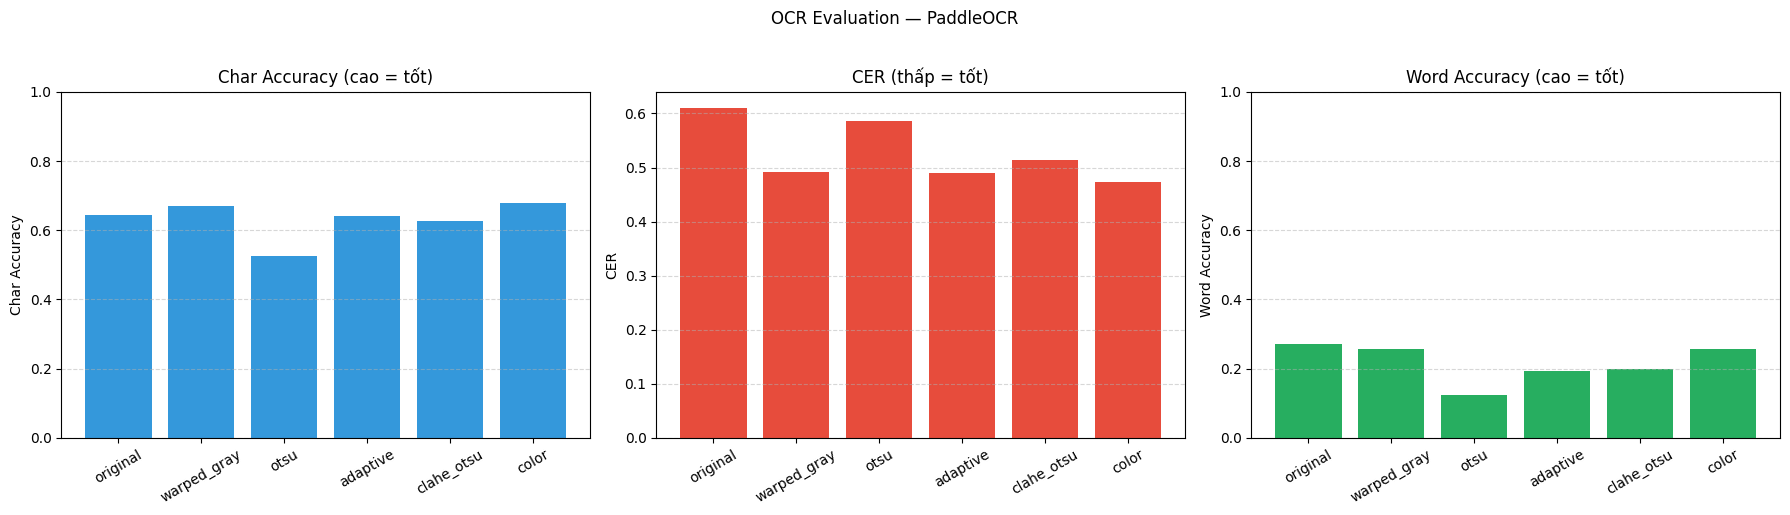

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

summary_idx = summary.set_index('variant').reindex(variant_order)

axes[0].bar(summary_idx.index, summary_idx['char_acc'], color='#3498db')
axes[0].set_title('Char Accuracy (cao = tốt)')
axes[0].set_ylabel('Char Accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(summary_idx.index, summary_idx['cer'], color='#e74c3c')
axes[1].set_title('CER (thấp = tốt)')
axes[1].set_ylabel('CER')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(summary_idx.index, summary_idx['word_acc'], color='#27ae60')
axes[2].set_title('Word Accuracy (cao = tốt)')
axes[2].set_ylabel('Word Accuracy')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('OCR Evaluation — PaddleOCR', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 9. Trực quan từng ảnh

6 panel cho 6 variant + in text dự đoán.

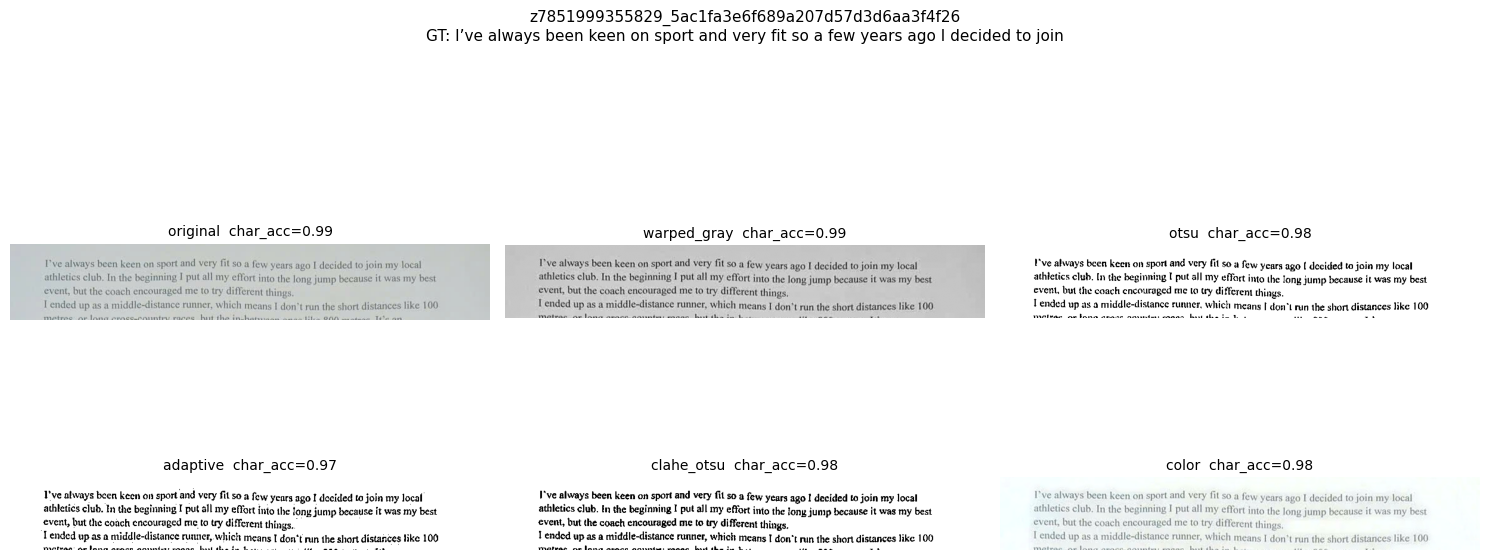

=== z7851999355829_5ac1fa3e6f689a207d57d3d6aa3f4f26 ===
GT  : I’ve always been keen on sport and very fit so a few years ago I decided to join my local athletics club. In the beginning I put all my effort into the long jump becasue it was my best avent, but the coach encouraged me to try different things. I ended up as a middle-distance runner, which means I don’t run the short distances like 100
  original      : I've always been keen on sport and very fit so a few years ago I decided to join my local athletics 
  warped_gray   : I've always been keen on sport and very fit so a few years ago I decided to join my local athletics 
  otsu          : l‘ve alvays been keen on sport and very fit so a few years ago I decided to join my local athietics 
  adaptive      : l've ałvays been keen on sport and very fit so a few years ago I decided to join my local athletics 
  clahe_otsu    : l've always been keen on sport and very fit so a few years ago I decided to join my local athletics 
  col

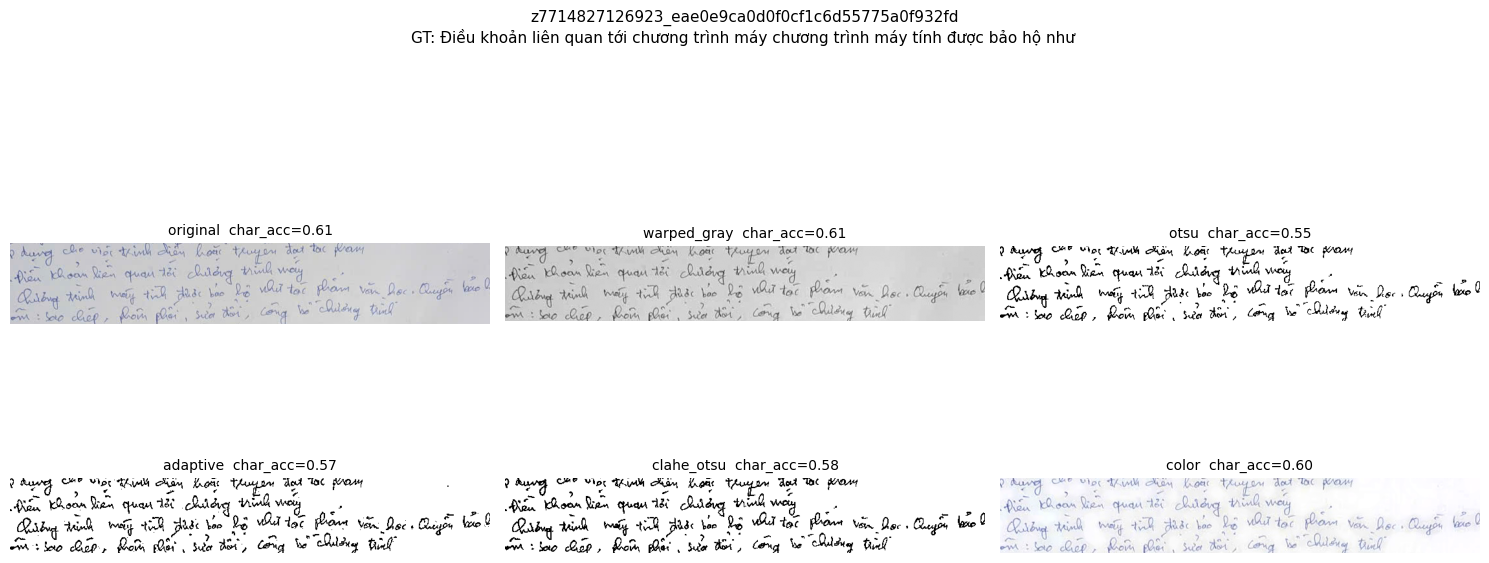

=== z7714827126923_eae0e9ca0d0f0cf1c6d55775a0f932fd ===
GT  : Điều khoản liên quan tới chương trình máy chương trình máy tính được bảo hộ như tác phẩm văn học. Quyền bảo âm: sao chép, phân phối, sửa đổi, công bố chương trình
  original      : p duvg cho vior tinh dien hour teuyen dat tac pram fien khoan lien quan ti ching trinh my Ching tinh
  warped_gray   : p duvg cho vior tinh dhen hour teuyen dat tac plram fien Khoan lien quan toi chilong trinh moy Chilb
  otsu          : o dung chd wiar tink dien hois tuger dat tac pram fin Khoan lin quan ti chiong trinh may Chidng tink
  adaptive      : dung cho viir tin dhen hou tuyen dat tac pramy Din Khoan lin quan ti chdng trinh may Chiing tink may
  clahe_otsu    : dung cho vipr trink dhen hoar tuyen dat tac pram Ain Khoan lin quan ti chidng trinh may Childng tink
  color         : p duvg cho vior thinh dhen hour teuyen dat tac plham fien khoan lien quan toi chileng thinh moy Chil



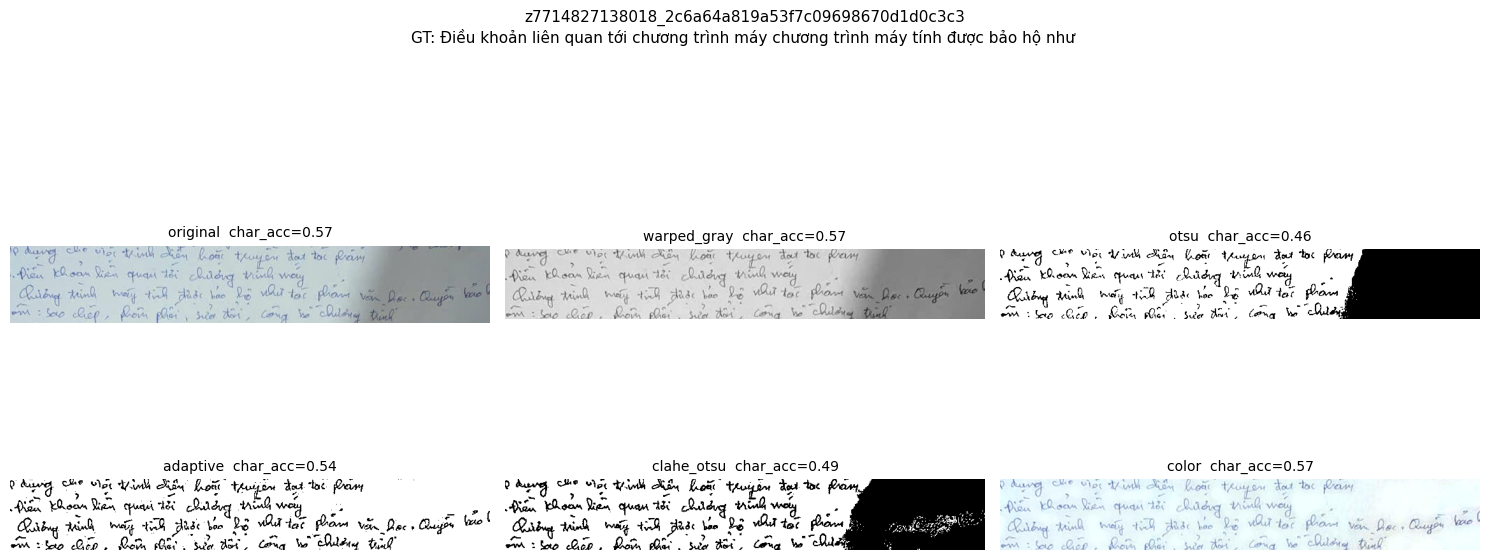

=== z7714827138018_2c6a64a819a53f7c09698670d1d0c3c3 ===
GT  : Điều khoản liên quan tới chương trình máy chương trình máy tính được bảo hộ như tác phẩm văn học. Quyền bảo âm: sao chép, phân phối, sửa đổi, công bố chương trình
  original      : p dung che vii thinh den hoi tewyen dar toc pran tin khoan lien quan ti chidng trinh my Chilong thin
  warped_gray   : p duvg che vior tinh chen hoir teuyen dat toc plram tien khoan lien quan ti chilsng thinh woy Chiong
  otsu          : o dung che via Vinh dian hor tayen dat tor pram Pin Khoan lin qua ti chidng trinl may Chiong tink mr
  adaptive      : ? divg o vior Vinh dn ho tuijen dat toc prasy Pien Khoan lin quni toi chldig trinl may Chibng tinh m
  clahe_otsu    : dung cho vior tinh din hor tvigin dat toc fram tin khoan lin quan ti childng trinh may Chienge think
  color         : p duvg che vior tinh dhon hoar teuyen dat toc plram fien khoan lien quan toi childng thinh woy Chilo



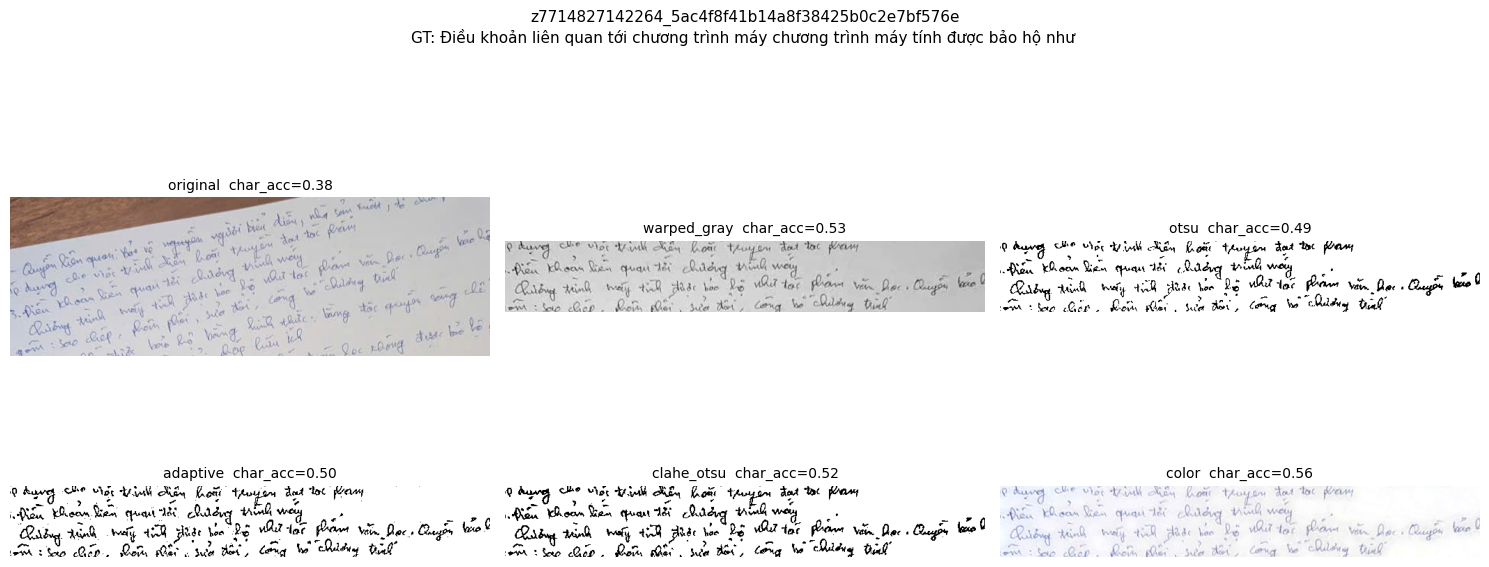

=== z7714827142264_5ac4f8f41b14a8f38425b0c2e7bf576e ===
GT  : Điều khoản liên quan tới chương trình máy chương trình máy tính được bảo hộ như tác phẩm văn học. Quyền bảo âm: sao chép, phân phối, sửa đổi, công bố chương trình
  original      : cilong tinl ip dung che vii tinh dn ha tenyen dat to pai Wo 3.Pin khoan lien quan ti ching tinl way 
  warped_gray   : P duveg cho vior tinh han hoar tiyen dat tac pram Pien Khoan lien quan tei chiong trinh woy Chilong 
  otsu          : pdng cho wiie tinh ian hou tyen dat tc pam in Khoan lin quan ti hueng trinl way Chidyge tind may tin
  adaptive      : P durgcho wiis tinl din houi toyen dat toc pam iin khoan dian quai i chdng trinl way Chilbnyg tinh r
  clahe_otsu    : o durg cho wiis tind dn hor' tyen dat toe pran in Khoan lin quan ti chaeng trink may Chidyg tinh mat
  color         : p duvg cho viir tinh han hoar tuyen dat toc plram Pien Khoan lien quan ti chisng thinh way Chiong te



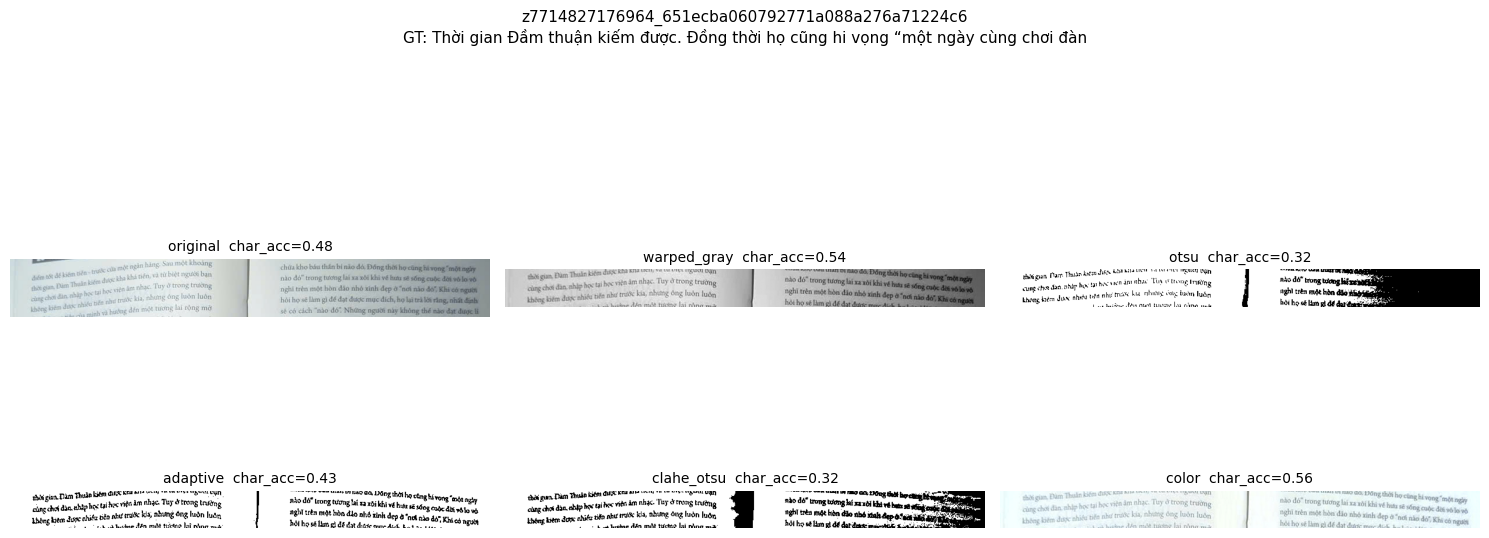

=== z7714827176964_651ecba060792771a088a276a71224c6 ===
GT  : Thời gian Đầm thuận kiếm được. Đồng thời họ cũng hi vọng “một ngày cùng chơi đàn, nhập học tại viện âm nhạc. Tuy ở trong trường nào đó” trong tương lai xa xôi khi về hưu sẽ sống cuộc đời vô lo vô không kiếm được nhiều tiền như trước kia nhưng ông luôn luôn nghĩ một hòn đảo nhỏ xinh đẹp ở “nơi nào đo”. Khi có người hỏi họ sẽ làm gì để đạt được
  original      : S chúa kho báu thán bí nào đó. Đóng thi ho cng hi vong "mt ngày đimtt dé kiém tn-tru camt ngn hng. S
  warped_gray   : nào dó" trong túơng lai xa xôi khi vé hutu sé sóng cuc di vó lo vó cng choi đan, nhăp ho tai hoc vin
  otsu          : thisgan Dar Thads kean duo, kha kild luu (uoj van nào dó" trong todnglitxe'w aghl trên mt hn dãob bs
  adaptive      : no đ Lrong tng lai za zikhi vé h se sóog co do v cng choida nhep h tihec nin im nhc. Tuy d trong tru
  clahe_otsu    : nào dó" trong tcnglai xaxdi kht vébs  b     l ln nghl tr mt hàn dão nbó iah ęp  hói ho se lám gi de

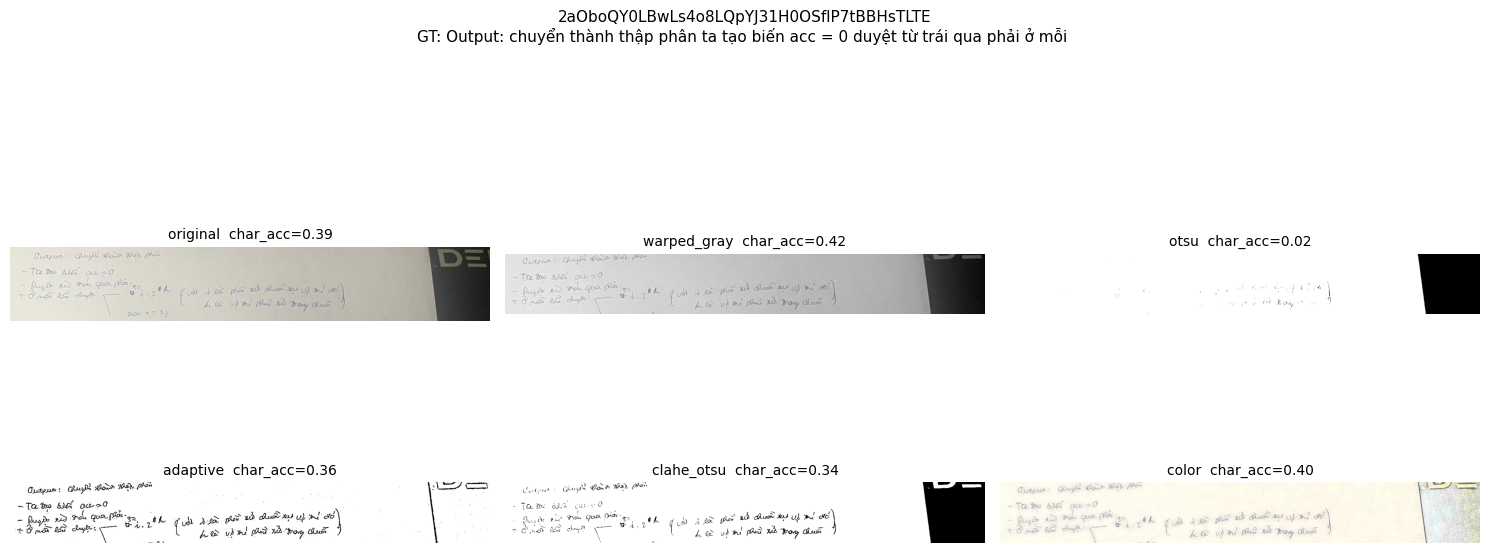

=== 2aOboQY0LBwLs4o8LQpYJ31H0OSflP7tBBHsTLTE ===
GT  : Output: chuyển thành thập phân ta tạo biến acc = 0 duyệt từ trái qua phải ở mỗi lần duyệt
  original      : DE Outpu: Chuyel taia then pror — Ta tee twr ace20 Pugi i u qua par S= èm (vd i la phoi ti duoi xu u
  warped_gray   : Outpuo: Chuyel thaia then phon -Tate t ace20 - Pugit ie s qua par S= èh (d i ea phov i dui xe u i dd
  otsu          : ; 7.
  adaptive      : O: C    -Ta b ao - Prgo  m qua pa è  (vd  la poi w dhi  u ti do Q-i.2 t8 mr la dry: h ud i p  tag d
  clahe_otsu    : ( : C a Ma  -Ta  co Pugd i  qua ie S= è  ( ad i a pi  caui x u mi dd bi.2 h Ca v i pa i targ chu
  color         : Outpw: Chuyel Wana then poi -Ta te war ace20 - Prgio ie an qua par SE èh (vd i ea poi si du  u i do 



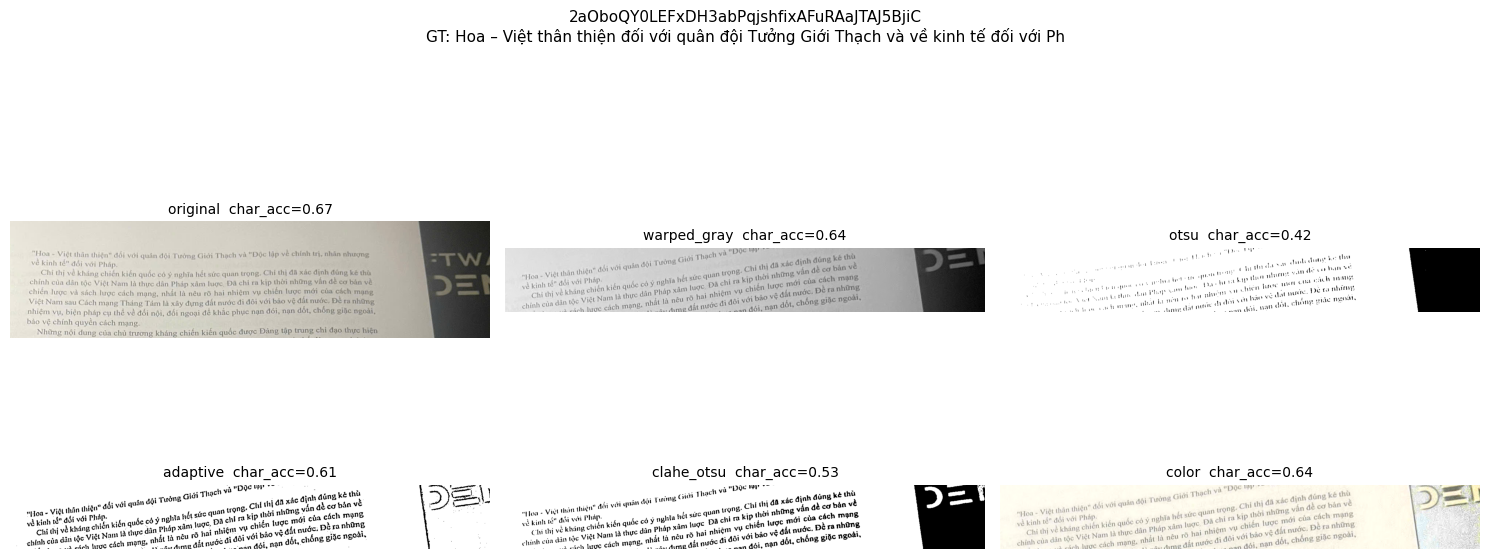

=== 2aOboQY0LEFxDH3abPqjshfixAFuRAaJTAJ5BjiC ===
GT  : Hoa – Việt thân thiện đối với quân đội Tưởng Giới Thạch và về kinh tế đối với Pháp Chỉ thị về kháng chiến kiến quốc có ý nghĩa hết sức quan trọng. Chỉ thị đã xác định đúng kẻ thù chính của dân tộc Việt Nam là thực dan Pháp xâm lược. Đã chỉ ra kịp thời những vấn đề cơ bản về lược cách mạng, nhất là nêu rõ hai nhiệm vụ chiến lược mới của cách mạng đất nước đi đôi với bảo vệ đất nước. Đề ra những đói, nạn dốt, chống giặc ngoài
  original      : "Hoa - Vit thân thin" đi vi qun đi Tưng Gii Thch và "Dc lp v chính tr, nhn nhưng :TW v kinh té" di v
  warped_gray   : D≡ "Hoa - Vit thân thin" đi vi quân đi Tưng Gii Thch và "Đc v kinh té" đi vi Pháp. Chi thj v kháng c
  otsu          : · .· . . · : i .g !ttg u: s ·tr qu n t h th  d du e thu tun m lp im ln Da. hua hyp t nlumg vin de oh
  adaptive      : "Hoa - Vit thn thin" đi vi qun đi Tưng Gii Thch v "Dč lj v kinh té"đi vói Pháp. Chi thij v kháng chi
  clahe_otsu    : 5= vè kinlı té" dói vái

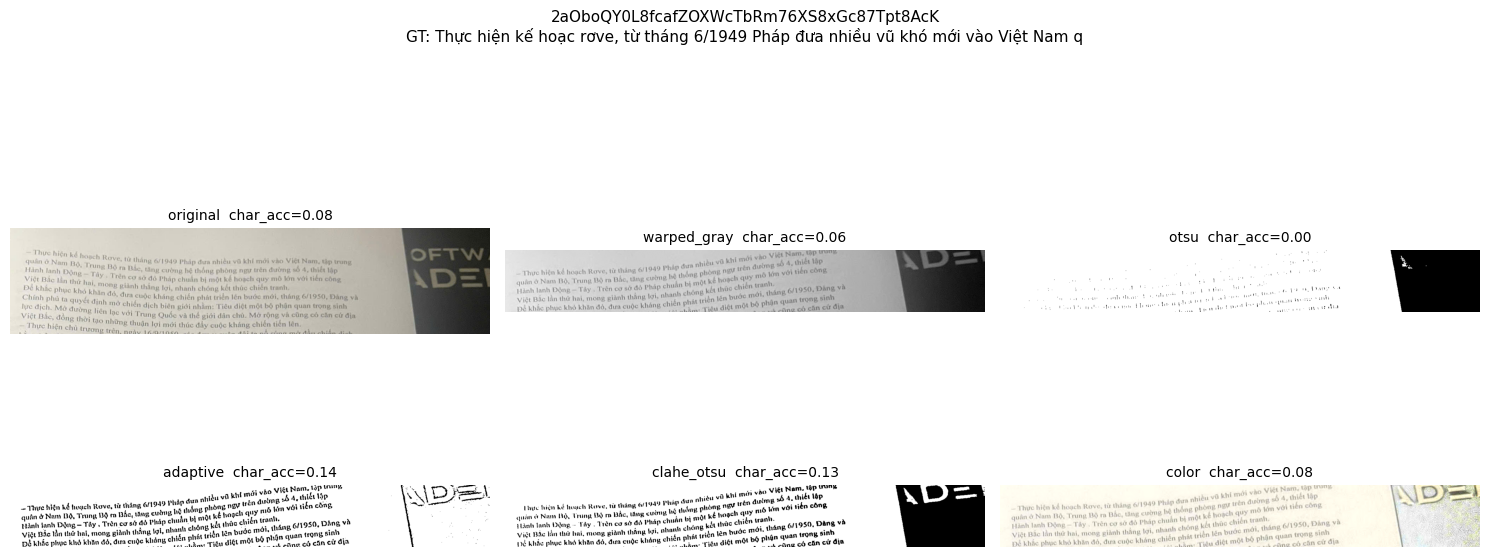

=== 2aOboQY0L8fcafZOXWcTbRm76XS8xGc87Tpt8AcK ===
GT  : Thực hiện kế hoạc rơve, từ tháng 6/1949 Pháp đưa nhiều vũ khó mới vào Việt Nam quân ở Nam Bộ, Trung Bộ ra Bắc, tăng cường hệ thống phòng ngự trên đường số 4, thiết lập Hành lang Đông – Tây. Trên cơ sở đó Pháp chuẩn bị một kế hoạch quy mô lớn với tiến công Việt Bắc lần thứ hai, mong giành thắng lợi, nhanh chóng kết thúc chiến tranh. Để khắc phục khó khăn đó, đưa cuộc kháng chiến phát triển lên bước mới, tháng 6/1950, Đảng và. Tiêu diệt một bộ phận quan trọng sinh có căn cứ địa
  original      : OFTW IDE iBhun thúcdcukngin.
  warped_gray   : ID= ūng có căn cú dja
  otsu          : 
  adaptive      : ęt möt bó plisn quan trng sinh cüne có cān cú dja
  clahe_otsu    : mt b phn qun trng sinh rüng có căn cú dn
  color         : nac cūng có căn cú dja



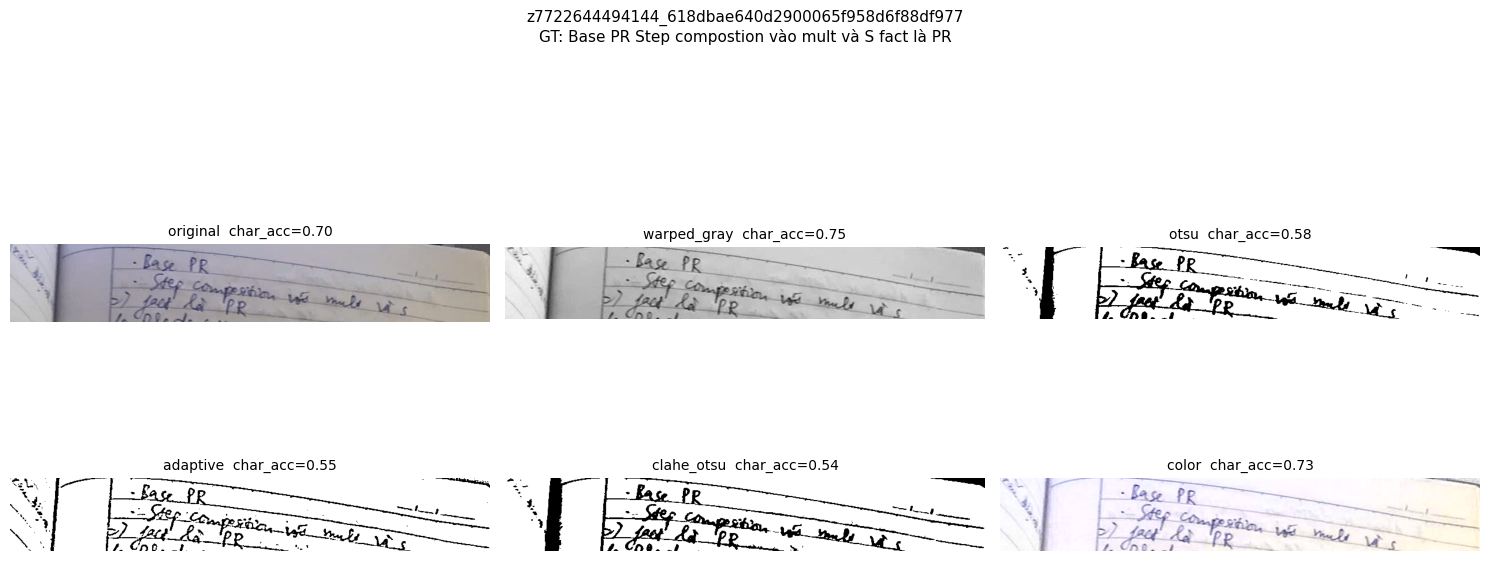

=== z7722644494144_618dbae640d2900065f958d6f88df977 ===
GT  : Base PR Step compostion vào mult và S fact là PR
  original      : ·Base PR  Step compsition us roul vi s ) 1act la PR lo Colede
  warped_gray   : .Base PR  Step composition ufs roul vi s ) 1acf la PR 0
  otsu          : .BasePR  Sep Campsition ua tl vis )Ine &PR T..
  adaptive      : .BasePR Step Compesidaniontl vas )1aULaPR T.C.
  clahe_otsu    : .BAse PR .Sep campesition -wa tle vis 2leet&aPR T. C..r
  color         : -Base PR  Step compsition ufs rul vi s ) 1acf la PR 1C0



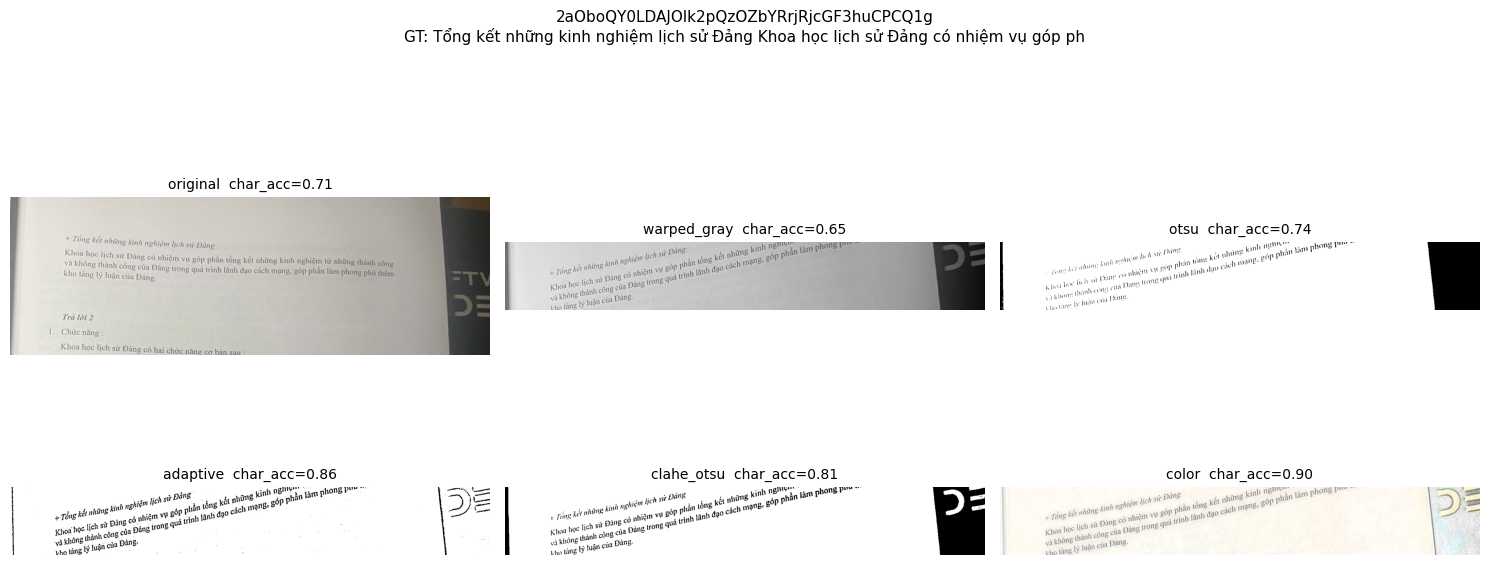

=== 2aOboQY0LDAJOlk2pQzOZbYRrjRjcGF3huCPCQ1g ===
GT  : Tổng kết những kinh nghiệm lịch sử Đảng Khoa học lịch sử Đảng có nhiệm vụ góp phần tổng kết những kinh và không thành công của Đảng trong quá trình lãnh đạo cách mạng, góp phần làm kho tàng lý luận của Đảng
  original      : + Tng kt nhng kinh nghim lch s Đng Khoa hc lch s Đng có nhim v góp phn tng kt nhng kinh nghim t nhng
  warped_gray   : D + Tng kt nhng kinh nghim lch s Đng Khoa hc lch s Đng có nhim v góp phn tng kt nhng kho tàng lý lun
  otsu          : • Ton: ket nhang kinh nghčm ch sic Dång Khoa hoe lh sů Dag cò nhim vu góp phn tng ket nhng ! Aì klón
  adaptive      : + Tng két nhng kinh nghim lich sů Đng Khoa hc lich sů Đng có nhim v góp phn tng kt nhng k và không t
  clahe_otsu    : t Tng két nhng kinh nghięm ljch si Dáng Khoa hąc lch sů Đng có nhim vμ góp phn tng kt nhng ki và khô
  color         : + Tng kt nhng kinh nghim lch s Đng Khoa hc lch s Đng có nhim v góp phân tng kt nhng ki và không thàn



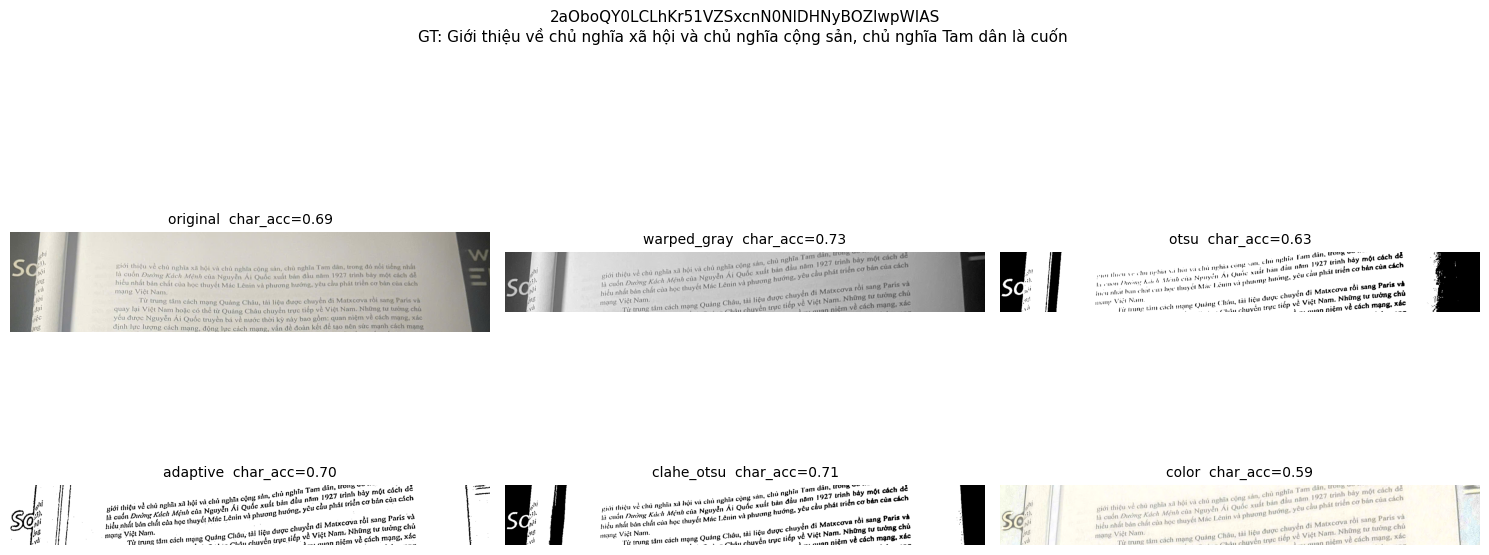

=== 2aOboQY0LCLhKr51VZSxcnN0NlDHNyBOZlwpWIAS ===
GT  : Giới thiệu về chủ nghĩa xã hội và chủ nghĩa cộng sản, chủ nghĩa Tam dân là cuốn Đường Kách Mệnh của Nguyễn Ái Quốc xuất bản đầu năm 1927 trình bày một cách dễ hiểu nhất bản chất của học thuyết Mác Lênin và phương hướng yêu cầu phát triển cơ bản của cách mạng Việt Nam Từ trung tâm cách mạng Quảng Chây, tài liệu được chuyển đi Matxcơva rồi sang Paris và chuyển trực tiếp về Việt Nam. Những tư tưởng chú niệm về cách mạng xác
  original      : 3lll ghi so 3), gii thiu v chù nghĩa xã hi và ch nghīa cng sn, chù nghīa Tam đân, trong đ ni tng nhá
  warped_gray   : giói thiu v chù nghĩa xã hi và chú nghīa cng sn, chù nghīa Tam dân, tron So là cun Đưng Kách Mnh ca 
  otsu          : ]1| ! tucu ve chu nybia vi hù va chú nghia cng an, chù nghia Tam dân, trong So La cuon Dcng  h nh ci
  adaptive      : hi So giói thiu v chù ngha xi hi vå chù ngha cng sůn, chù ngha Tơm din, trony là cun Dưng Kách Mnh c
  clahe_otsu    : h giói thięu v chù nghia x

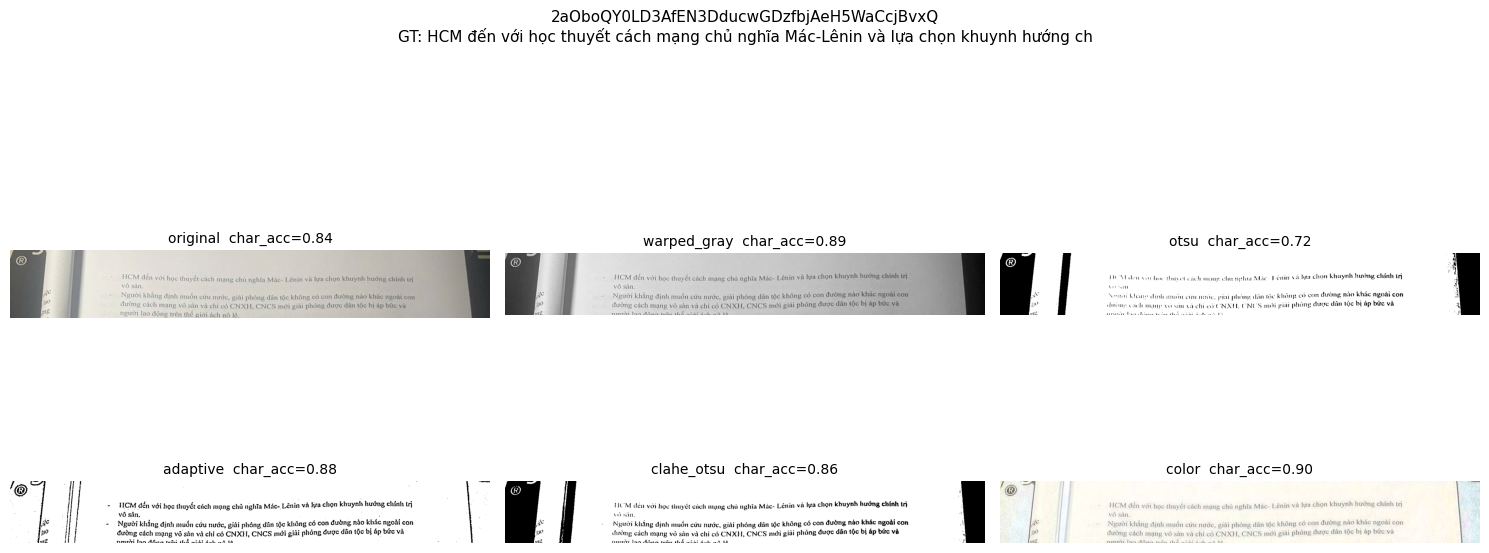

=== 2aOboQY0LD3AfEN3DducwGDzfbjAeH5WaCcjBvxQ ===
GT  : HCM đến với học thuyết cách mạng chủ nghĩa Mác-Lênin và lựa chọn khuynh hướng chính trị vô sản.  Người khẳng định muốn cứu nước, giải phóng dân tộc không có con đường nào khác ngoài con đường cách mạng vô sản và chỉ có CNXH, CNCS mới giải phóng được dân tộc bị áp bức và
  original      : R HCM đn vi hc thuyt cách mng chů nghīa Mác- Lênin và la chn khuynh hưng chính trj vô sån. viec Ngưi
  warped_gray   : ® HCM đn vi hc thuyt cách mng chů ngha Mác- Lênin và la chn khuynh hưng chính trj vô sån. viec Ngưi 
  otsu          : 1e λ1 den vut hoc thu et cach mang chu ngha Me. 1 énin và lra chon khuynh lưng chnt tri A  i'.,I i k
  adaptive      : HCM đn vi hc thyt cńch mng chů ngha Mác- Lênin và ļa chn khuynh hưng chnh trj vô săn. itc Ngưi khng 
  clahe_otsu    : k'M đn vi hc thyt cich mng ch ngha Mác- Lênin v la chn khuynh hưng chnh tj vāsin. c Ngưi khng đnh mu
  color         : R HCM đn vi hc thuyt cách mng chů nghīa Mác- Lênin và la chn 

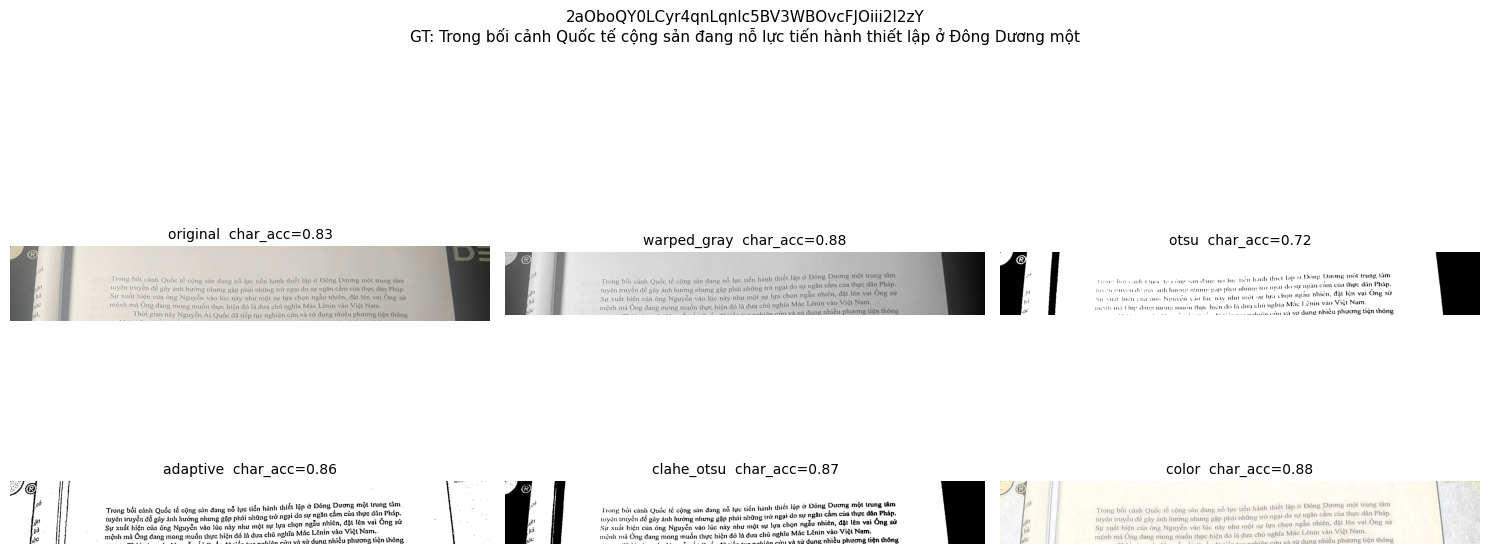

=== 2aOboQY0LCyr4qnLqnlc5BV3WBOvcFJOiii2I2zY ===
GT  : Trong bối cảnh Quốc tế cộng sản đang nỗ lực tiến hành thiết lập ở Đông Dương một trung tâm tuyên truyền để gây ảnh hưởng nhung gặp phải những trở ngại do sự ngăn cấm của thực dân Pháp. Sự xuất hiện của ông Nguyễn vào kucs này như một sự lựa chọn ngẫu nhiên, đặt lên vai Ông sứ mệnh mà Ông đang mong muốn thực hiện đó là đưa chủ nghĩa Mác Lênin vào Vieeth Nam và sử dụng nhiều phương tiện thông
  original      : có Trong bi cành Quc té cng sn đang n lưc tin hành thit lp  Đng Dương mt trung tâm Uain tuyên truyn 
  warped_gray   : ® có Trong bi cành Quc t cng sn đang n lc tin hành thit lp  Đông Dương mt trung tâm tuyên truyn đ gâ
  otsu          : , o Lton: lui canh Guod te cong san dang nu lue tn hånh tuct làp u Dóng Dưong môt trung tâm Iuen tnv
  adaptive      : Trong bi cnh Quc t cong sn đang n lưe tin hnh thit lp  Đông Dương mt ưrung tm tuyên truyn đ gây åntı
  clahe_otsu    : Trong bi cành Quc té cng sn đng n lưc tin hnh thit lp  Đô

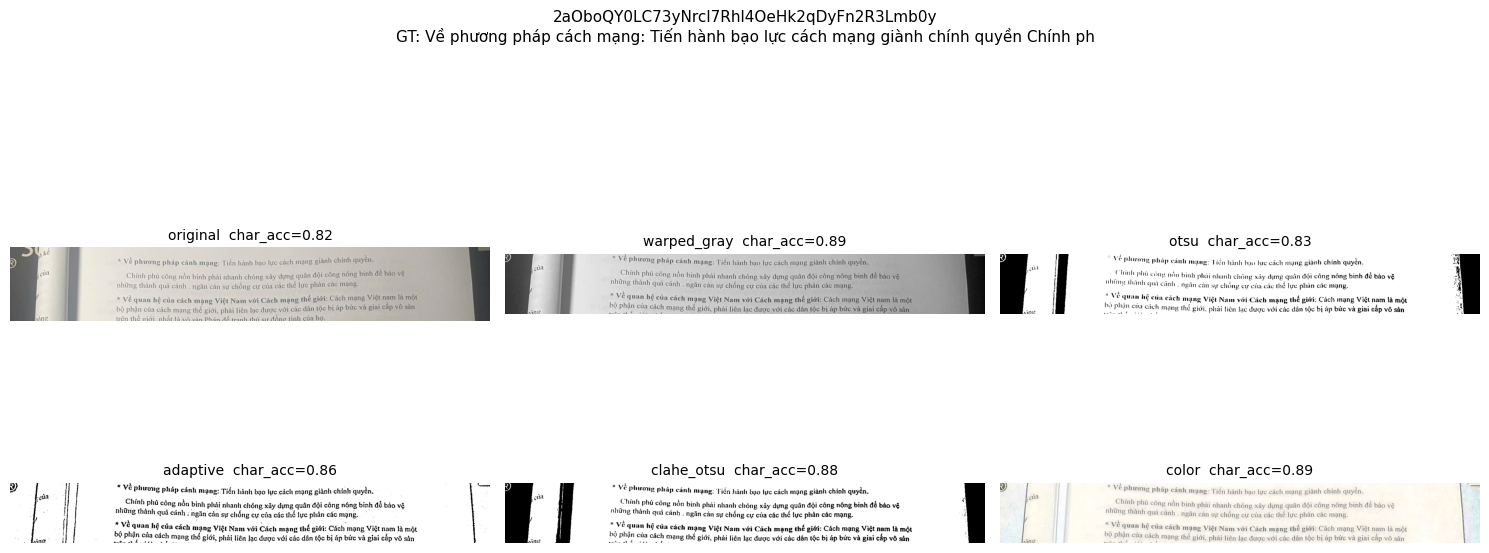

=== 2aOboQY0LC73yNrcl7Rhl4OeHk2qDyFn2R3Lmb0y ===
GT  : Về phương pháp cách mạng: Tiến hành bạo lực cách mạng giành chính quyền Chính phủ công dồ binh phải nhanh chóng xây dựng quân đội công nông binh để bảo vệ những thành quả cánh ngăn cản sự chống cự của các thế lực phản cách mạng Về quan hệ của cách mạng Việt Nam bới Cách mạng thế giới: Cách mạng Việt Nam là một bộ phận của cách mạng thế giới, phải liên tục được với các dân tộc bị áp bức và giai cấp vô sản
  original      : hké * V phưong pháp cánh mng: Tin hành bo lc cách mng giành chính quyn. cúa Chính phù công nn binh p
  warped_gray   : * V phưong pháp cánh mng: Tin hành bo lc cách mng giành chính quyn. cúa Chính phù công nn binh phi n
  otsu          : :: V phưrong pháp enh mng: Tin hành bo le cách mng giành chính quyn. I Lù hinh plù cng nn binh phài 
  adaptive      : * V phưrong pháp cánh mng: Tin hnhı bo lưe cách mng giànhı chnh quyn. ;cúa Chính phů công nn binh ph
  clahe_otsu    : * V phưong pháp cánh mng: Tin hànhı bo lc c

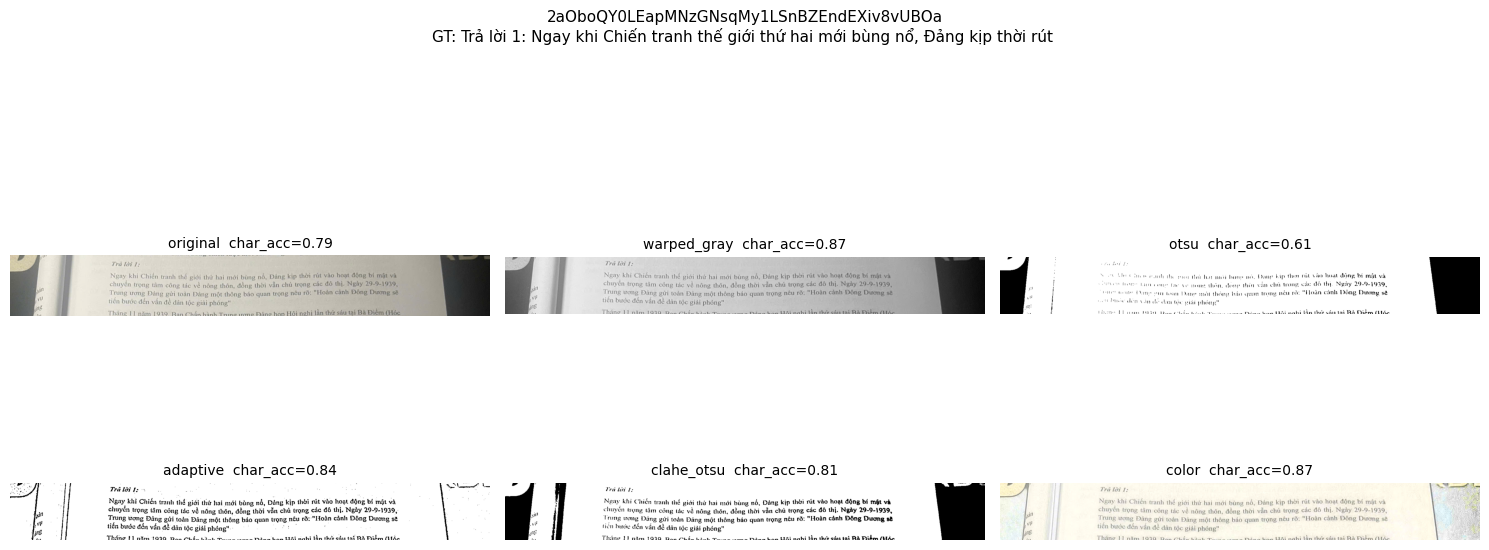

=== 2aOboQY0LEapMNzGNsqMy1LSnBZEndEXiv8vUBOa ===
GT  : Trả lời 1: Ngay khi Chiến tranh thế giới thứ hai mới bùng nổ, Đảng kịp thời rút vào hoạt động bí mật và chuyển trọng tâm công tác về nông thôn, đồng thời vẫn chú trọng các đô thị. Ngày 29-9-1939, trung ương Đảng gửi toàn Đảng một thông báo quan trọng nêu rõ: Hoàn cảnh Đông Dương sẽ tiến bước đến vấn đề dân tộc giải phóng
  original      : Trå lòi 1: Ngay khi Chin tranh th gii th hai mi bng n, Đng kip thi rt vào hot đng bí mt và chuyn trn
  warped_gray   : Tră lòi I: Ngay khi Chin tranh th gii th hai mi bng n, Đng kip thi rút vào hot đng bí mt và chuyn tr
  otsu          : . ;.. /,•/ :   :  t nh th  th ha mi bung . Đany kip th rút vo hot đng bi mt và • ue fro- 1in +o: ta 
  adaptive      : Trā li 1: : - Ngay khi Chin tranhı thé gii tl hai mi bng n, Dng kip thi rút vào hot đng bí mt va chu
  clahe_otsu    : Trà tòi 1: Ngay khi Chin tranh th gii th hai mi bng n, Dng kip thi rt vào hot đng bí mt và chuyn trn
  color         : Tră lòi 1

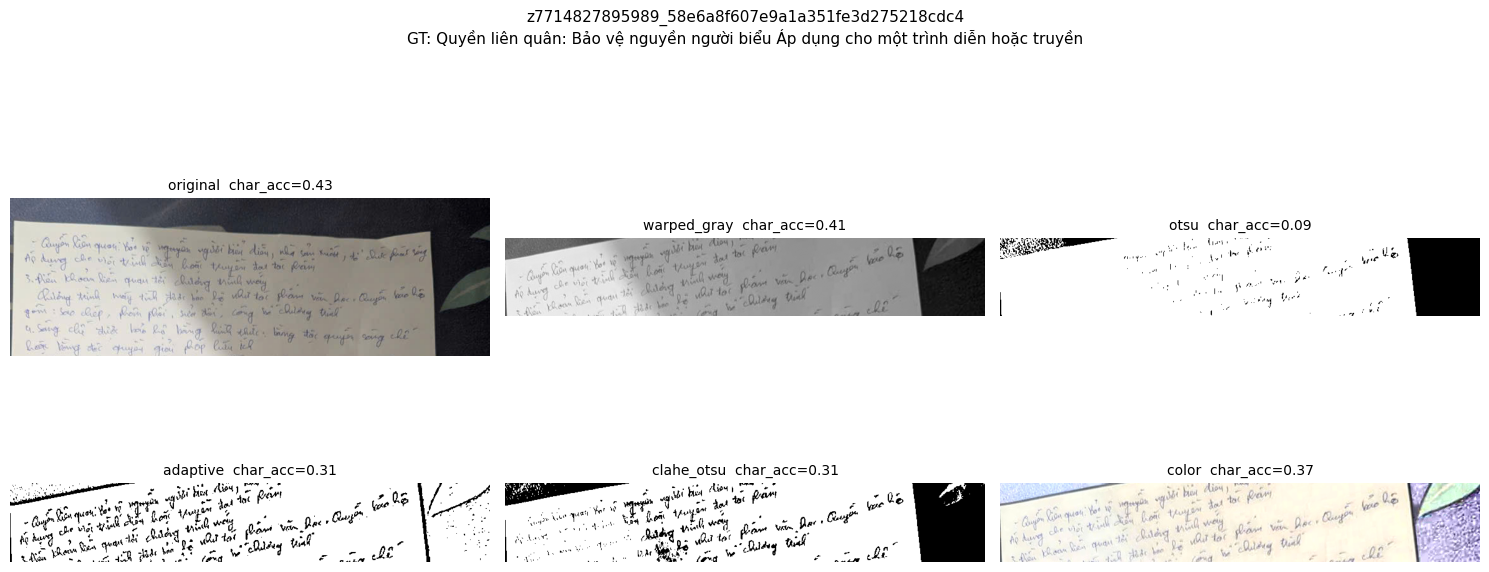

=== z7714827895989_58e6a8f607e9a1a351fe3d275218cdc4 ===
GT  : Quyền liên quân: Bảo vệ nguyền người biểu Áp dụng cho một trình diễn hoặc truyền đạt tác phẩm Điều khoản kiên quan tới chương trình máy được bảo vệ như tác phẩm văn học. Quyền bảo hộ công bố chương trình
  original      : Qq A dung che vir thinh don hai teuyen dat to par 3.Aen khoan lien quan ti chidng minil way Chg     
  warped_gray   : A dung che v tin d ha tey dt t pairy 3 f thoin lien quan toi hadig minl mey g hi chiloy thil in che-
  otsu          : . . t t doe " Ud
  adaptive      : A hug c  ti  h tyn d t Rm  tho ls qugy ti chadg tril way cli
  clahe_otsu    : ∴r .∴  ho tuyer dat toc pan a  whit ta plam vn Dar Cayn bilo 1. hadig til wy. e
  color         : A dung che v tin dn ha t d t pai y he childny til g che 3 fin thoan lien quau toi childig tinl way



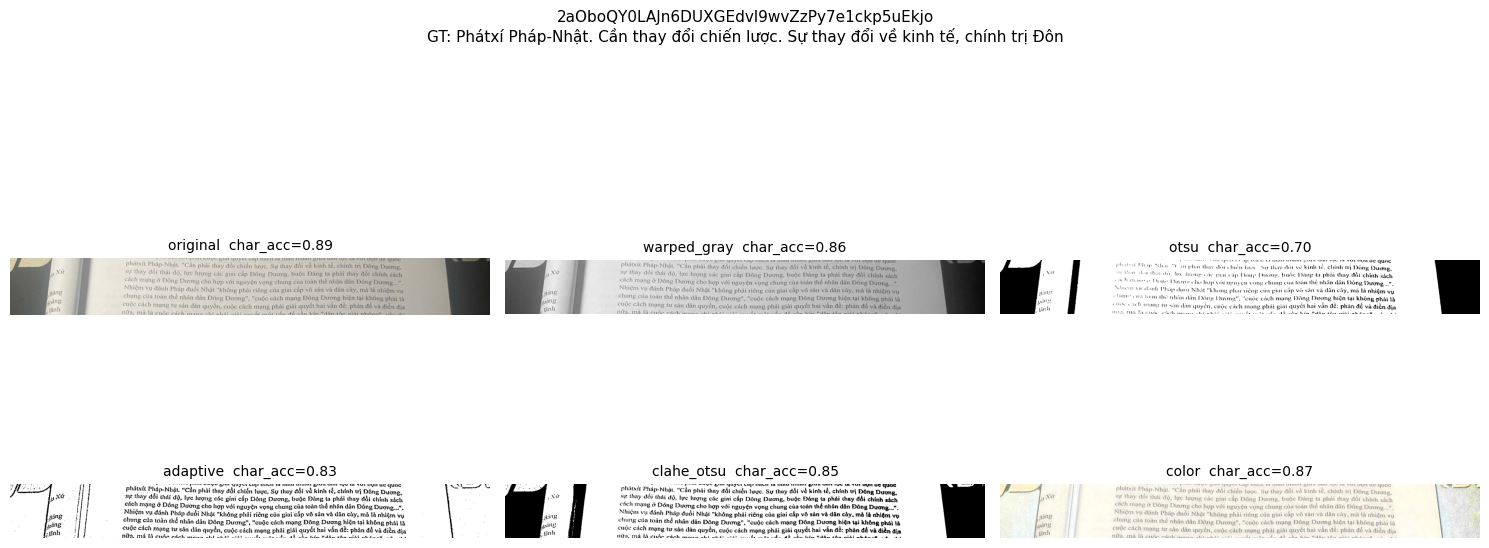

=== 2aOboQY0LAJn6DUXGEdvl9wvZzPy7e1ckp5uEkjo ===
GT  : Phátxí Pháp-Nhật. Cần thay đổi chiến lược. Sự thay đổi về kinh tế, chính trị Đông Dương. Sự thay đổi thái độ, lực lượng các giai cấp Đông Dương, buộc Đảng ta phải thay đổi chính sách cách mạng ở Đông Dương cho hợp với nguyện vọng chưng của toàn thể nhân dân Đông Dương... Nhiệm vụ đánh Pháp đuổi Nhật không phải riêng của giai cấp vô sản và dân cày, mà là nhiệm vụ chung của toàn thể nhân đân Đông Dương, cuộc cách mạng Đông Dương hiện tại không phải là cuộc cách mạng tư sản dân quyền, cuộc cách mạng phải giải quyết hai vấn đề: phản đề và điền địa
  original      : phátxít Pháp-Nht. "Cn phi thay đi chin lưc. S thay đi v kinh t, chính tr Đông Dương, s thay đi thái 
  warped_gray   : phátxít Pháp-Nht. "Cn phi thay đi chin lưc. S thay đi v kinh t, chính tr Đông Dương. sr thay đi thái
  otsu          : ¿lteit l'hip: Nhu "t mn phau tbav đi clun lnn Sur thay di vè kinh t. chính tri Dông Dưmg. Vtr i d du
  adaptive      : phátxít Pháp-Nht. "C

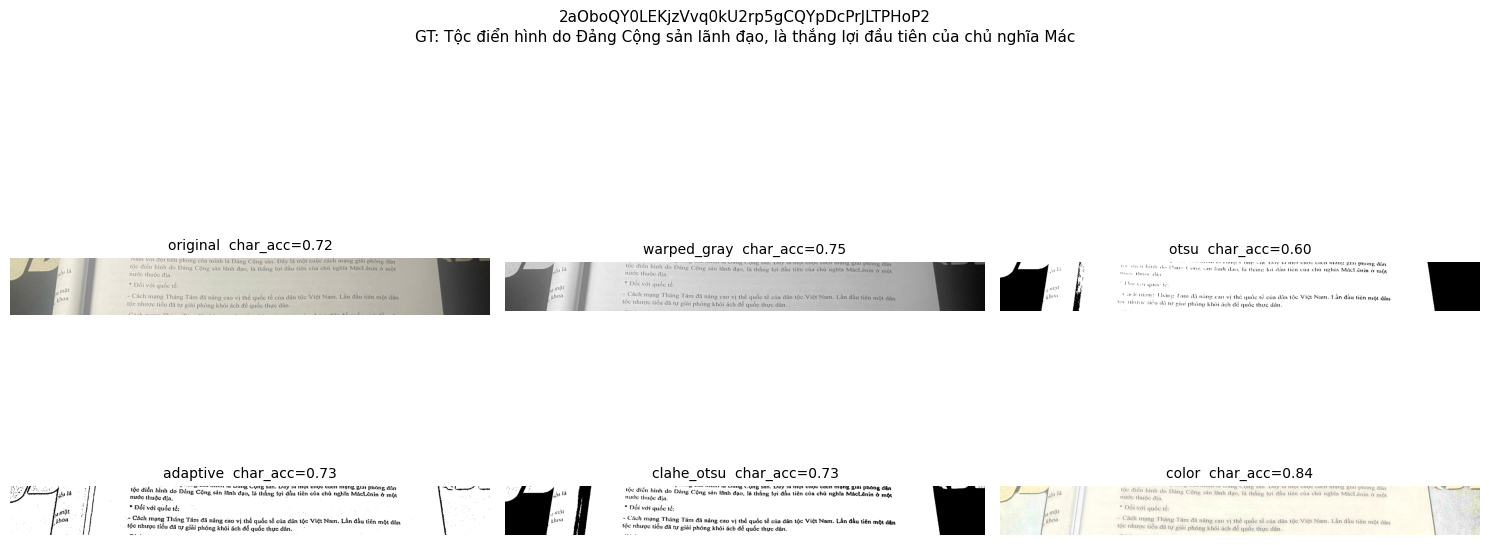

=== 2aOboQY0LEKjzVvq0kU2rp5gCQYpDcPrJLTPHoP2 ===
GT  : Tộc điển hình do Đảng Cộng sản lãnh đạo, là thắng lợi đầu tiên của chủ nghĩa MácLênin ở nước thuộc địa Đối với quốc tế Cách mạng Tháng Tám đã nâng cao vị thế quốc tế của dân tộc Việt Nam. Lần đầu tiên một dân tộc nhược tiểu đã tự giải phòng khỏi ác đế quốc thực dân
  original      : Nam vi đi tiên phong ca mình là Đng Cng sn. Đây là mt cuc cách mng gii phóng dân tc đin hinh do Đng 
  warped_gray   : tc đin hinh do Đâng Cng sn lānh đo, là thng li đu tiên ca ch nghīa MácLênin  mt aong ca minn la Đang
  otsu          : la cit o hinhi do Dano Cong sin Lnh dao, lå tháng loi diu tién cúa chú nghía Máelênin à mót Tm: cr T
  adaptive      : tc đin hinh do Đâng Cng sn lănh đo, là thng li đu tin ca chú ngha Máclênin & mt ong cd ilin la Đang 
  clahe_otsu    : lc đin hinh do Đng Cng sn lānh đo, là thng li đu tiên ca ch nghīa Máclênin  mt g Cda iliinn l Dang C
  color         : tc đin hinh do Đâng Cng sn lānh đo, là thng li đu tiên ca chú nghī

In [ ]:
for stem, cache in predictions_cache.items():
    crops = cache['crops']
    preds = cache['preds']
    gt_text = items[stem]['ground_truth']

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    axes = axes.flatten()

    for ax, variant in zip(axes, ALL_VARIANTS):
        img = crops.get(variant)
        if img is None or img.size == 0:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            ax.axis('off')
            continue
        if len(img.shape) == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        row = df[(df['stem'] == stem) & (df['variant'] == variant)]
        acc = row['char_acc'].iloc[0] if len(row) else 0.0
        ax.set_title(f'{variant}  char_acc={acc:.2f}', fontsize=10)
        ax.axis('off')

    plt.suptitle(f'{stem}\nGT: {gt_text[:80]}', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f'=== {stem} ===')
    print(f'GT  : {gt_text}')
    for variant in ALL_VARIANTS:
        pred = preds.get(variant, '').strip().replace('\n', ' | ')
        print(f'  {variant:14s}: {pred[:100]}')
    print()

## 10. Merge với kết quả Tesseract


In [ ]:
tesseract_summary_path = EVAL_DIR / 'ocr_summary_tesseract.csv'

if tesseract_summary_path.exists():
    tesseract_df = pd.read_csv(tesseract_summary_path)
    merged = pd.concat([tesseract_df, summary], ignore_index=True)

    pivot_char = merged.pivot(index='variant', columns='engine', values='char_acc').reindex(variant_order)
    pivot_char['mean'] = pivot_char.mean(axis=1).round(4)
    print('Char Accuracy (cả 2 engine):')
    display(pivot_char.round(4))

    merged.to_csv(EVAL_DIR / 'ocr_summary_combined.csv', index=False)
    print(f'\nLưu combined → {EVAL_DIR / "ocr_summary_combined.csv"}')
else:
    print(f'Chưa có file Tesseract ({tesseract_summary_path}), skip merge.')
    print('Sau khi NB05 chạy xong, chạy lại cell này để có bảng tổng hợp.')


Char Accuracy (cả 2 engine):


engine,paddleocr,tesseract,mean
variant,,,
original,0.6445,0.5218,0.5832
warped_gray,0.6699,0.5914,0.6306
otsu,0.5256,0.5124,0.5190
adaptive,0.6410,0.6122,0.6266
clahe_otsu,0.6260,0.6120,0.6190
color,0.6784,0.6030,0.6407



Lưu combined → /content/drive/MyDrive/DataCV/dataset/test/test_detection/eval_run/ocr_summary_combined.csv
